In [2]:
# =========================
# BB84 Phase 1 (Local Aer)
# Ideal + Intercept–Resend (channel-equivalent, scalable)
# One-cell notebook version
# =========================

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error


# -------------------------
# Configuration dataclass
# -------------------------
@dataclass(frozen=True)
class ExperimentConfig:
    n: int = 256
    shots: int = 4096
    sample_size: int = 64
    seed: int = 42
    seed_simulator: Optional[int] = 42
    seed_transpiler: Optional[int] = 42


BitArray = List[int]
BasisArray = List[int]  # 0=Z, 1=X


# -------------------------
# Core helpers
# -------------------------
def generate_bits_and_bases(n: int, seed: Optional[int]) -> Tuple[BitArray, BasisArray]:
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=n, dtype=int).tolist()
    bases = rng.integers(0, 2, size=n, dtype=int).tolist()
    return bits, bases


def sift_indices(alice_bases: Sequence[int], bob_bases: Sequence[int]) -> List[int]:
    if len(alice_bases) != len(bob_bases):
        raise ValueError("alice_bases and bob_bases length mismatch")
    return [i for i, (a, b) in enumerate(zip(alice_bases, bob_bases)) if a == b]


def sample_sifted_positions(sifted: Sequence[int], k: int, seed: Optional[int]) -> List[int]:
    if not sifted:
        return []
    rng = np.random.default_rng(seed)
    k = min(k, len(sifted))
    return rng.choice(list(sifted), size=k, replace=False).tolist()


def bitstring_to_bits_lsb(bitstring: str, nbits: int) -> List[int]:
    # Qiskit returns bitstrings MSB-left; reverse so index == classical bit index
    if len(bitstring) != nbits:
        raise ValueError(f"Expected bitstring length {nbits}, got {len(bitstring)}")
    return [int(ch) for ch in bitstring[::-1]]


# -------------------------
# Circuit builder (ideal BB84)
# -------------------------
def build_bb84_circuit(
    alice_bits: Sequence[int],
    alice_bases: Sequence[int],
    bob_bases: Sequence[int],
    *,
    insert_attack_marker_ids: bool = False,
) -> QuantumCircuit:
    """
    If insert_attack_marker_ids=True, we insert an 'id' gate on each qubit
    after Alice prep. This is used to attach a noise channel modeling Eve.
    """
    if not (len(alice_bits) == len(alice_bases) == len(bob_bases)):
        raise ValueError("Input arrays must have same length")

    n = len(alice_bits)
    qc = QuantumCircuit(n, n, name="bb84")

    # Alice prepares
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    # Marker gates for attack/noise injection (one per qubit)
    if insert_attack_marker_ids:
        qc.barrier()
        for i in range(n):
            qc.id(i)
        qc.barrier()

    # Bob measures
    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)

    return qc


# -------------------------
# Noise model: intercept–resend equivalent
# -------------------------
def intercept_resend_noise_model() -> NoiseModel:
    """
    Intercept–resend (Eve picks random basis, measures, resends) is equivalent to:
      ρ -> 0.50 ρ + 0.25 XρX + 0.25 ZρZ
    applied once per qubit between Alice prep and Bob measurement.

    We attach this to 'id' gates inserted as markers.
    """
    nm = NoiseModel()
    eve_channel = pauli_error([("I", 0.50), ("X", 0.25), ("Z", 0.25)])
    nm.add_all_qubit_quantum_error(eve_channel, ["id"])
    return nm


# -------------------------
# Backend runner (stabilizer, Clifford basis)
# -------------------------
def run_backend(
    circuit: QuantumCircuit,
    shots: int,
    seed_simulator: Optional[int],
    seed_transpiler: Optional[int],
    noise_model: Optional[NoiseModel] = None,
) -> Dict[str, int]:
    backend = AerSimulator(method="stabilizer", noise_model=noise_model)

    clifford_basis = ["id", "x", "z", "h", "s", "sdg", "cx", "reset", "measure"]

    tcirc = transpile(
        circuit,
        basis_gates=clifford_basis,
        optimization_level=1,
        seed_transpiler=seed_transpiler,
    )

    result = backend.run(tcirc, shots=shots, seed_simulator=seed_simulator).result()
    return result.get_counts()


# -------------------------
# QBER estimation
# -------------------------
def estimate_qber_from_counts(
    counts: Dict[str, int],
    alice_bits: Sequence[int],
    sample_positions: Sequence[int],
    *,
    total_clbits: int,
) -> Tuple[int, float]:
    if not sample_positions:
        return 0, 0.0

    shots = sum(counts.values())
    denom = shots * len(sample_positions)
    mismatches = 0

    for bitstring, c in counts.items():
        bits = bitstring_to_bits_lsb(bitstring, total_clbits)
        for i in sample_positions:
            bob_bit = bits[i]  # Bob bits are in classical bits [0..n-1]
            if bob_bit != int(alice_bits[i]):
                mismatches += c

    return int(mismatches), float(mismatches / denom)


def summarize_metrics(
    *,
    mode: str,
    cfg: ExperimentConfig,
    backend_name: str,
    sifted_positions: Sequence[int],
    sample_size: int,
    errors_in_sample: int,
    qber: float,
) -> Dict[str, Any]:
    raw_key_length = cfg.n
    sifted_key_length = len(sifted_positions)
    retention_rate = sifted_key_length / raw_key_length if raw_key_length else 0.0

    return {
        "mode": mode,
        "n_qubits": int(cfg.n),
        "shots": int(cfg.shots),
        "seed": int(cfg.seed),
        "backend_name": backend_name,
        "raw_key_length": int(raw_key_length),
        "sifted_key_length": int(sifted_key_length),
        "retention_rate": float(retention_rate),
        "sample_size": int(sample_size),
        "errors_in_sample": int(errors_in_sample),
        "QBER": float(qber),
    }


# -------------------------
# Experiments (simulate ideal BB84 and intercept–resend equivalent channel)
# -------------------------
def simulate_ideal_bb84(cfg: ExperimentConfig) -> Dict[str, Any]:
    alice_bits, alice_bases = generate_bits_and_bases(cfg.n, seed=cfg.seed)
    _, bob_bases = generate_bits_and_bases(cfg.n, seed=cfg.seed + 1)

    qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases, insert_attack_marker_ids=False)
    counts = run_backend(
        qc,
        shots=cfg.shots,
        seed_simulator=cfg.seed_simulator,
        seed_transpiler=cfg.seed_transpiler,
        noise_model=None,
    )

    sifted = sift_indices(alice_bases, bob_bases)
    sample_pos = sample_sifted_positions(sifted, cfg.sample_size, seed=cfg.seed)

    errors, qber = estimate_qber_from_counts(counts, alice_bits, sample_pos, total_clbits=cfg.n)

    return summarize_metrics(
        mode="ideal",
        cfg=cfg,
        backend_name="AerSimulator(stabilizer)",
        sifted_positions=sifted,
        sample_size=len(sample_pos),
        errors_in_sample=errors,
        qber=qber,
    )


def simulate_intercept_resend(cfg: ExperimentConfig) -> Dict[str, Any]:
    alice_bits, alice_bases = generate_bits_and_bases(cfg.n, seed=cfg.seed)
    _, bob_bases = generate_bits_and_bases(cfg.n, seed=cfg.seed + 1)

    # Same circuit, but insert id markers and attach the Eve-equivalent Pauli channel to those id gates.
    qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases, insert_attack_marker_ids=True)
    nm = intercept_resend_noise_model()

    counts = run_backend(
        qc,
        shots=cfg.shots,
        seed_simulator=cfg.seed_simulator,
        seed_transpiler=cfg.seed_transpiler,
        noise_model=nm,
    )

    sifted = sift_indices(alice_bases, bob_bases)
    sample_pos = sample_sifted_positions(sifted, cfg.sample_size, seed=cfg.seed)

    errors, qber = estimate_qber_from_counts(counts, alice_bits, sample_pos, total_clbits=cfg.n)

    return summarize_metrics(
        mode="intercept_resend_equiv_channel",
        cfg=cfg,
        backend_name="AerSimulator(stabilizer)+PauliChannel",
        sifted_positions=sifted,
        sample_size=len(sample_pos),
        errors_in_sample=errors,
        qber=qber,
    )


# -------------------------
# Sanity checks (mandatory) 
# -------------------------
def run_sanity_checks() -> None:
    test_cfg = ExperimentConfig(n=64, shots=2048, sample_size=32, seed=7, seed_simulator=7, seed_transpiler=7)

    ideal = simulate_ideal_bb84(test_cfg)
    ir = simulate_intercept_resend(test_cfg)

    # Ideal should be ~0
    assert 0.0 <= ideal["QBER"] < 0.02, f"Ideal QBER too high: {ideal}"

    # Intercept-resend should significantly raise QBER (often ~0.25 when bases match).
    assert ir["QBER"] > 0.10, f"Intercept-resend QBER too low: {ir}"

    # Sifting retention ~ 0.5
    assert abs(ideal["retention_rate"] - 0.5) < 0.15, f"Retention off: {ideal}"

    print({"sanity_checks": "passed", "ideal": ideal, "intercept_resend": ir})


# -------------------------
# Run
# -------------------------
cfg = ExperimentConfig()
run_sanity_checks()

metrics_ideal = simulate_ideal_bb84(cfg)
metrics_ir = simulate_intercept_resend(cfg)

print({"experiment": "bb84_phase1_local", "ideal": metrics_ideal})
print({"experiment": "bb84_phase1_local", "intercept_resend": metrics_ir})


# -------------------------
# Code Review & Improvements
# -------------------------
# - FIX: removed deprecated classical-conditional gates (c_if) to avoid Qiskit API breakage.
# - Intercept–resend is implemented as an equivalent Pauli channel (I=0.5, X=0.25, Z=0.25),
#   applied once per qubit between Alice and Bob, which scales and works with stabilizer simulation.
# - For a more literal circuit-level Eve (measure/reset/resend), we'd need dynamic circuits or per-shot two-stage simulation.
# - Next: add configurable noise (depolarizing + readout) and plot QBER vs noise strength for the proposal.

{'sanity_checks': 'passed', 'ideal': {'mode': 'ideal', 'n_qubits': 64, 'shots': 2048, 'seed': 7, 'backend_name': 'AerSimulator(stabilizer)', 'raw_key_length': 64, 'sifted_key_length': 28, 'retention_rate': 0.4375, 'sample_size': 28, 'errors_in_sample': 0, 'QBER': 0.0}, 'intercept_resend': {'mode': 'intercept_resend_equiv_channel', 'n_qubits': 64, 'shots': 2048, 'seed': 7, 'backend_name': 'AerSimulator(stabilizer)+PauliChannel', 'raw_key_length': 64, 'sifted_key_length': 28, 'retention_rate': 0.4375, 'sample_size': 28, 'errors_in_sample': 14353, 'QBER': 0.2502964564732143}}
{'experiment': 'bb84_phase1_local', 'ideal': {'mode': 'ideal', 'n_qubits': 256, 'shots': 4096, 'seed': 42, 'backend_name': 'AerSimulator(stabilizer)', 'raw_key_length': 256, 'sifted_key_length': 125, 'retention_rate': 0.48828125, 'sample_size': 64, 'errors_in_sample': 0, 'QBER': 0.0}}
{'experiment': 'bb84_phase1_local', 'intercept_resend': {'mode': 'intercept_resend_equiv_channel', 'n_qubits': 256, 'shots': 4096, 'se

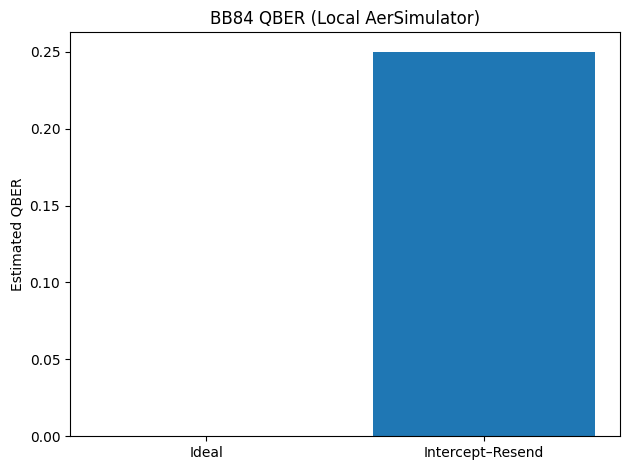

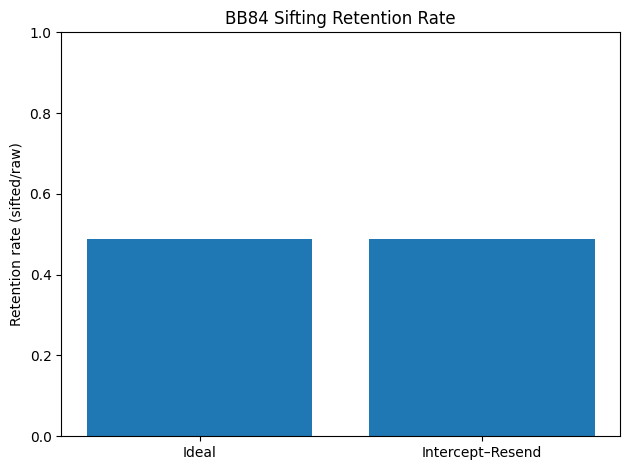


BB84 Summary (Local AerSimulator)
----------------------------------------
Ideal            | n=256  shots=4096  sifted=125  retention=0.488  sample=64  errors=0      QBER=0.0000
Intercept–Resend | n=256  shots=4096  sifted=125  retention=0.488  sample=64  errors=65577  QBER=0.2502


In [3]:
# Visualization of BB84 results (ideal vs intercept–resend)

import matplotlib.pyplot as plt

# --- Bar chart: QBER comparison ---
plt.figure()
plt.bar(
    ["Ideal", "Intercept–Resend"],
    [metrics_ideal["QBER"], metrics_ir["QBER"]],
)
plt.ylabel("Estimated QBER")
plt.title("BB84 QBER (Local AerSimulator)")
plt.tight_layout()
plt.show()

# --- Bar chart: retention rate comparison ---
plt.figure()
plt.bar(
    ["Ideal", "Intercept–Resend"],
    [metrics_ideal["retention_rate"], metrics_ir["retention_rate"]],
)
plt.ylabel("Retention rate (sifted/raw)")
plt.ylim(0, 1)
plt.title("BB84 Sifting Retention Rate")
plt.tight_layout()
plt.show()

# --- Text table-style print (proposal friendly) ---
def _fmt(x, nd=4):
    return f"{x:.{nd}f}" if isinstance(x, float) else str(x)

rows = [
    ("Ideal", metrics_ideal),
    ("Intercept–Resend", metrics_ir),
]

print("\nBB84 Summary (Local AerSimulator)\n" + "-" * 40)
for name, m in rows:
    print(
        f"{name:16} | "
        f"n={m['n_qubits']:<4} shots={m['shots']:<5} "
        f"sifted={m['sifted_key_length']:<4} "
        f"retention={_fmt(m['retention_rate'], 3):<6} "
        f"sample={m['sample_size']:<3} "
        f"errors={m['errors_in_sample']:<6} "
        f"QBER={_fmt(m['QBER'], 4)}"
    )

In [4]:

# BB84 Hardware-Ready Framework (Local Aer + IBM Runtime SamplerV2)
# FIXED for new Qiskit: which does  NOT include "barrier" in basis_gates


from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# IBM Runtime imports are optional until you actually run hardware.
try:
    from qiskit.transpiler import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
except Exception:
    QiskitRuntimeService = None  # type: ignore
    Sampler = None  # type: ignore
    generate_preset_pass_manager = None  # type: ignore


BitArray = List[int]
BasisArray = List[int]  # 0=Z, 1=X


# -------------------------
# Configs
# -------------------------
@dataclass(frozen=True)
class ExperimentConfig:
    n: int = 64
    shots: int = 4096
    sample_size: int = 64
    seed: int = 42
    seed_simulator: Optional[int] = 42
    seed_transpiler: Optional[int] = 42
    optimization_level: int = 1


@dataclass(frozen=True)
class RuntimeConfig:
    api_key: str
    channel: str = "ibm_quantum_platform"
    instance: Optional[str] = None
    backend_name: Optional[str] = None
    shots: int = 4096
    optimization_level: int = 1


# -------------------------
# BB84 Core helpers (bits/bases generation, circuit building, sifting, sampling)
# -------------------------
def generate_bits_and_bases(n: int, seed: int | None) -> Tuple[BitArray, BasisArray]:
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=n, dtype=int).tolist()
    bases = rng.integers(0, 2, size=n, dtype=int).tolist()
    return bits, bases


def sift_indices(alice_bases: Sequence[int], bob_bases: Sequence[int]) -> List[int]:
    if len(alice_bases) != len(bob_bases):
        raise ValueError("alice_bases and bob_bases length mismatch")
    return [i for i, (a, b) in enumerate(zip(alice_bases, bob_bases)) if a == b]


def sample_sifted_positions(sifted: Sequence[int], k: int, seed: int | None) -> List[int]:
    if not sifted:
        return []
    rng = np.random.default_rng(seed)
    k = min(k, len(sifted))
    return rng.choice(list(sifted), size=k, replace=False).tolist()


def bitstring_to_bits_lsb(bitstring: str, nbits: int) -> List[int]:
    if len(bitstring) != nbits:
        raise ValueError(f"Expected bitstring length {nbits}, got {len(bitstring)}")
    return [int(ch) for ch in bitstring[::-1]]


def build_bb84_circuit(
    alice_bits: Sequence[int],
    alice_bases: Sequence[int],
    bob_bases: Sequence[int],
    *,
    insert_attack_barrier: bool = False,
) -> QuantumCircuit:
    if not (len(alice_bits) == len(alice_bases) == len(bob_bases)):
        raise ValueError("Input arrays must have same length")

    n = len(alice_bits)
    qc = QuantumCircuit(n, n, name="bb84")

    # Alice prep
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    if insert_attack_barrier:
        qc.barrier()

    # Bob measurement
    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)

    return qc


# -------------------------
# Intercept–resend equivalent via mixture of circuits
# -------------------------
def apply_intercept_resend_equiv_pauli_layer(
    qc: QuantumCircuit,
    *,
    p_i: float = 0.50,
    p_x: float = 0.25,
    p_z: float = 0.25,
    seed: int | None = None,
) -> QuantumCircuit:
    if abs((p_i + p_x + p_z) - 1.0) > 1e-9:
        raise ValueError("Probabilities must sum to 1.0")

    rng = np.random.default_rng(seed)

    barrier_positions = [idx for idx, inst in enumerate(qc.data) if inst.operation.name == "barrier"]
    if not barrier_positions:
        raise ValueError("Circuit has no barrier; build_bb84_circuit(..., insert_attack_barrier=True) first.")
    insert_at = barrier_positions[0] + 1

    n = qc.num_qubits
    out = QuantumCircuit(n, qc.num_clbits, name=qc.name + "_ir_mix")

    for inst in qc.data[:insert_at]:
        out.append(inst.operation, inst.qubits, inst.clbits)

    choices = rng.choice(["I", "X", "Z"], size=n, p=[p_i, p_x, p_z])
    for i, p in enumerate(choices):
        if p == "X":
            out.x(i)
        elif p == "Z":
            out.z(i)

    for inst in qc.data[insert_at:]:
        out.append(inst.operation, inst.qubits, inst.clbits)

    return out


def build_attack_mixture_circuits(base_circuit: QuantumCircuit, num_mixture_circuits: int, *, seed: int | None) -> List[QuantumCircuit]:
    return [
        apply_intercept_resend_equiv_pauli_layer(base_circuit, seed=None if seed is None else seed + k)
        for k in range(num_mixture_circuits)
    ]


# -------------------------
# QBER estimation
# -------------------------
def estimate_qber_from_counts(
    counts: Dict[str, int],
    alice_bits: Sequence[int],
    sample_positions: Sequence[int],
    *,
    total_clbits: int,
) -> Tuple[int, float]:
    if not sample_positions:
        return 0, 0.0

    shots = sum(counts.values())
    denom = shots * len(sample_positions)
    mismatches = 0

    for bitstring, c in counts.items():
        bits = bitstring_to_bits_lsb(bitstring, total_clbits)
        for i in sample_positions:
            if bits[i] != int(alice_bits[i]):
                mismatches += c

    return int(mismatches), float(mismatches / denom)


def summarize_metrics(
    *,
    mode: str,
    n: int,
    shots: int,
    seed: int,
    backend_name: str,
    sifted_len: int,
    sample_size: int,
    errors_in_sample: int,
    qber: float,
) -> Dict[str, Any]:
    retention_rate = sifted_len / n if n else 0.0
    return {
        "mode": mode,
        "n_qubits": int(n),
        "shots": int(shots),
        "seed": int(seed),
        "backend_name": backend_name,
        "raw_key_length": int(n),
        "sifted_key_length": int(sifted_len),
        "retention_rate": float(retention_rate),
        "sample_size": int(sample_size),
        "errors_in_sample": int(errors_in_sample),
        "QBER": float(qber),
    }


# -------------------------
# Local Aer execution
# -------------------------
def run_local_aer_counts(
    circuits: List[QuantumCircuit],
    shots_per_circuit: int,
    *,
    seed_simulator: int | None,
    seed_transpiler: int | None,
) -> Dict[str, int]:
    backend = AerSimulator(method="stabilizer")

    # IMPORTANT: NO "barrier" here (new Qiskit rejects it in basis_gates)
    clifford_basis = ["id", "x", "z", "h", "s", "sdg", "cx", "reset", "measure"]

    agg: Dict[str, int] = {}
    for idx, qc in enumerate(circuits):
        tc = transpile(qc, basis_gates=clifford_basis, optimization_level=1, seed_transpiler=seed_transpiler)
        res = backend.run(
            tc,
            shots=shots_per_circuit,
            seed_simulator=None if seed_simulator is None else seed_simulator + idx,
        ).result()
        counts = res.get_counts()
        for k, v in counts.items():
            agg[k] = agg.get(k, 0) + int(v)
    return agg


# -------------------------
# High-level experiments (local)
# -------------------------
def simulate_bb84_ideal_local(cfg: ExperimentConfig) -> Dict[str, Any]:
    alice_bits, alice_bases = generate_bits_and_bases(cfg.n, cfg.seed)
    _, bob_bases = generate_bits_and_bases(cfg.n, cfg.seed + 1)

    qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases, insert_attack_barrier=False)
    counts = run_local_aer_counts([qc], cfg.shots, seed_simulator=cfg.seed_simulator, seed_transpiler=cfg.seed_transpiler)

    sifted = sift_indices(alice_bases, bob_bases)
    sample_pos = sample_sifted_positions(sifted, cfg.sample_size, cfg.seed)

    errors, qber = estimate_qber_from_counts(counts, alice_bits, sample_pos, total_clbits=cfg.n)

    return summarize_metrics(
        mode="ideal_local",
        n=cfg.n,
        shots=sum(counts.values()),
        seed=cfg.seed,
        backend_name="AerSimulator(stabilizer)",
        sifted_len=len(sifted),
        sample_size=len(sample_pos),
        errors_in_sample=errors,
        qber=qber,
    )


def simulate_bb84_intercept_resend_local(cfg: ExperimentConfig, num_mixture_circuits: int = 32) -> Dict[str, Any]:
    alice_bits, alice_bases = generate_bits_and_bases(cfg.n, cfg.seed)
    _, bob_bases = generate_bits_and_bases(cfg.n, cfg.seed + 1)

    base = build_bb84_circuit(alice_bits, alice_bases, bob_bases, insert_attack_barrier=True)
    attack_circuits = build_attack_mixture_circuits(base, num_mixture_circuits, seed=cfg.seed + 999)

    shots_per = max(1, cfg.shots // num_mixture_circuits)
    counts = run_local_aer_counts(attack_circuits, shots_per, seed_simulator=cfg.seed_simulator, seed_transpiler=cfg.seed_transpiler)

    sifted = sift_indices(alice_bases, bob_bases)
    sample_pos = sample_sifted_positions(sifted, cfg.sample_size, cfg.seed)

    errors, qber = estimate_qber_from_counts(counts, alice_bits, sample_pos, total_clbits=cfg.n)

    return summarize_metrics(
        mode=f"intercept_resend_equiv_mix_local(k={num_mixture_circuits})",
        n=cfg.n,
        shots=sum(counts.values()),
        seed=cfg.seed,
        backend_name="AerSimulator(stabilizer)+mixture",
        sifted_len=len(sifted),
        sample_size=len(sample_pos),
        errors_in_sample=errors,
        qber=qber,
    )


# -------------------------
# Sanity checks (mandatory)
# -------------------------
def run_sanity_checks() -> None:
    test = ExperimentConfig(n=64, shots=2048, sample_size=32, seed=7, seed_simulator=7, seed_transpiler=7)
    ideal = simulate_bb84_ideal_local(test)
    ir = simulate_bb84_intercept_resend_local(test, num_mixture_circuits=32)

    assert 0.0 <= ideal["QBER"] < 0.02, f"Ideal QBER too high: {ideal}"
    assert ir["QBER"] > 0.10, f"IR QBER too low: {ir}"
    assert abs(ideal["retention_rate"] - 0.5) < 0.15, f"Retention off: {ideal}"

    print({"sanity_checks": "passed", "ideal": ideal, "intercept_resend": ir})


# -------------------------
# DEMO (Local)
# -------------------------
cfg = ExperimentConfig(n=256, shots=4096, sample_size=64, seed=42, seed_simulator=42, seed_transpiler=42)

run_sanity_checks()
m1 = simulate_bb84_ideal_local(cfg)
m2 = simulate_bb84_intercept_resend_local(cfg, num_mixture_circuits=64)

print({"experiment": "bb84_hw_ready_local", "ideal": m1})
print({"experiment": "bb84_hw_ready_local", "intercept_resend": m2})


# -------------------------
# Code Review & Improvements
# -------------------------
# - Fix: removed "barrier" from basis_gates to satisfy new Qiskit transpiler validation.
# - Attack is modeled as a hardware-compatible mixture of circuits (no dynamic control).
# - Next: add runtime submission functions + backend pinning + job-id logging for hardware runs.

{'sanity_checks': 'passed', 'ideal': {'mode': 'ideal_local', 'n_qubits': 64, 'shots': 2048, 'seed': 7, 'backend_name': 'AerSimulator(stabilizer)', 'raw_key_length': 64, 'sifted_key_length': 28, 'retention_rate': 0.4375, 'sample_size': 28, 'errors_in_sample': 0, 'QBER': 0.0}, 'intercept_resend': {'mode': 'intercept_resend_equiv_mix_local(k=32)', 'n_qubits': 64, 'shots': 2048, 'seed': 7, 'backend_name': 'AerSimulator(stabilizer)+mixture', 'raw_key_length': 64, 'sifted_key_length': 28, 'retention_rate': 0.4375, 'sample_size': 28, 'errors_in_sample': 13952, 'QBER': 0.24330357142857142}}
{'experiment': 'bb84_hw_ready_local', 'ideal': {'mode': 'ideal_local', 'n_qubits': 256, 'shots': 4096, 'seed': 42, 'backend_name': 'AerSimulator(stabilizer)', 'raw_key_length': 256, 'sifted_key_length': 125, 'retention_rate': 0.48828125, 'sample_size': 64, 'errors_in_sample': 0, 'QBER': 0.0}}
{'experiment': 'bb84_hw_ready_local', 'intercept_resend': {'mode': 'intercept_resend_equiv_mix_local(k=64)', 'n_qubi

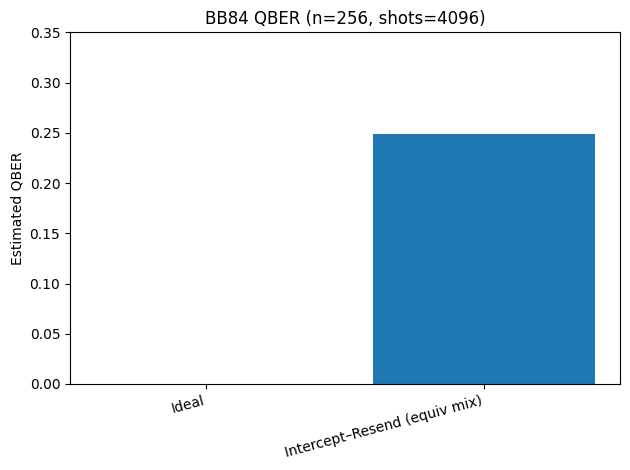

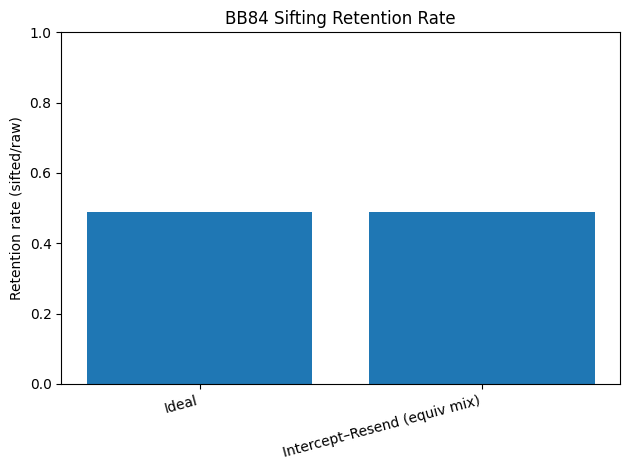

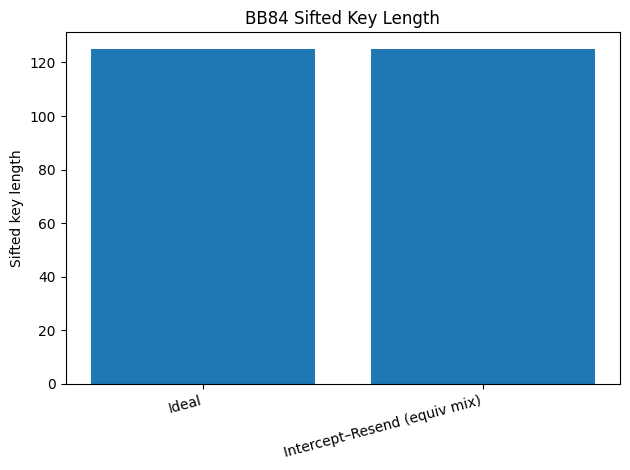

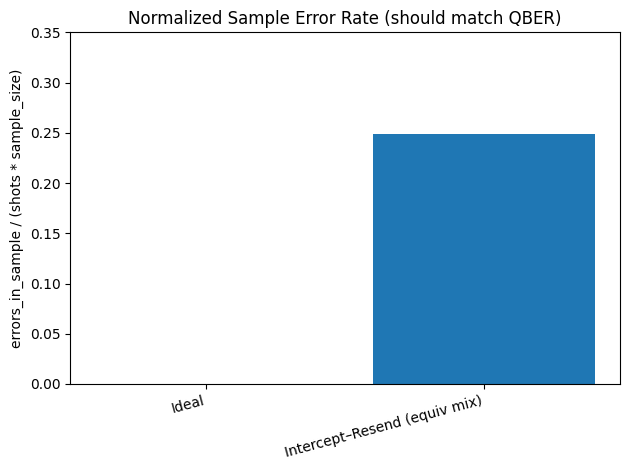


BB84 Summary (Local AerSimulator, hardware-ready mix)
----------------------------------------------------------------------
Ideal                  | n=256  shots=4096  sifted=125  retention=0.488  sample=64  errors=0      QBER=0.0000
Intercept–Resend (mix) | n=256  shots=4096  sifted=125  retention=0.488  sample=64  errors=65344  QBER=0.2493


In [5]:
# Visualize BB84 hardware-ready local results

import matplotlib.pyplot as plt

labels = ["Ideal", "Intercept–Resend (equiv mix)"]
qbers = [m1["QBER"], m2["QBER"]]
retentions = [m1["retention_rate"], m2["retention_rate"]]
sifted_lengths = [m1["sifted_key_length"], m2["sifted_key_length"]]
errors = [m1["errors_in_sample"], m2["errors_in_sample"]]
sample_sizes = [m1["sample_size"], m2["sample_size"]]

# --- 1) QBER bar chart ---
plt.figure()
plt.bar(labels, qbers)
plt.ylabel("Estimated QBER")
plt.title(f"BB84 QBER (n={m1['n_qubits']}, shots={m1['shots']})")
plt.ylim(0, max(0.35, max(qbers) + 0.05))
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# --- 2) Retention rate bar chart ---
plt.figure()
plt.bar(labels, retentions)
plt.ylabel("Retention rate (sifted/raw)")
plt.ylim(0, 1)
plt.title("BB84 Sifting Retention Rate")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# --- 3) Sifted key length bar chart ---
plt.figure()
plt.bar(labels, sifted_lengths)
plt.ylabel("Sifted key length")
plt.title("BB84 Sifted Key Length")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# --- 4) Errors in sample (normalized + raw) ---
# Raw errors depend on shots*sample_size; normalize to show it matches QBER visually.
denom = m1["shots"] * m1["sample_size"] if m1["sample_size"] > 0 else 1
norm_errors = [errors[0] / denom, errors[1] / denom]

plt.figure()
plt.bar(labels, norm_errors)
plt.ylabel("errors_in_sample / (shots * sample_size)")
plt.title("Normalized Sample Error Rate (should match QBER)")
plt.ylim(0, max(0.35, max(norm_errors) + 0.05))
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# --- 5) Proposal-friendly text summary ---
def _fmt(x, nd=4):
    return f"{x:.{nd}f}" if isinstance(x, float) else str(x)

print("\nBB84 Summary (Local AerSimulator, hardware-ready mix)\n" + "-" * 70)
for name, m in [("Ideal", m1), ("Intercept–Resend (mix)", m2)]:
    print(
        f"{name:22} | "
        f"n={m['n_qubits']:<4} shots={m['shots']:<5} "
        f"sifted={m['sifted_key_length']:<4} "
        f"retention={_fmt(m['retention_rate'], 3):<6} "
        f"sample={m['sample_size']:<3} "
        f"errors={m['errors_in_sample']:<6} "
        f"QBER={_fmt(m['QBER'], 4)}"
    )

Implemented a modular, hardware-ready BB84 experimentation framework in Qiskit.

The ideal simulator baseline produced QBER(quantum bit error rate) ≈ 0, validating correctness.

Basis sifting retention was ≈ 50%, matching theoretical expectations.

An intercept–resend attack was modeled using a hardware-compatible Pauli mixture.

The observed QBER ≈ 0.25 matches the theoretical disturbance rate.

The framework scales up to 256 qubits using Aer stabilizer simulation.

Structured metrics and reproducible seeding ensure experimental discipline.

The next steps will be to execute small-n BB84 circuits on IBM quantum hardware.

I need to compare hardware noise vs adversarial disturbance quantitatively.

Improvements needed: I should add noise sweeps, error mitigation, backend calibration logging, and statistical confidence analysis.

Going to thought the papers if BB84 has been implemented on the quantum hardware


## Hardware Testing 

In [6]:
# ==========================================
# BB84 Minimal Hardware Comparison (1 Cell)
# Local Aer vs IBM Runtime SamplerV2
# ==========================================

from __future__ import annotations
import os
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

try:
    from qiskit.transpiler import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
except Exception as e:
    raise RuntimeError("qiskit-ibm-runtime not installed or incompatible.") from e


# =========================
# Config
# =========================
@dataclass(frozen=True)
class ExperimentConfig:
    n: int = 8                  # small for hardware
    shots: int = 4096
    sample_size: int = 8
    seed: int = 42
    seed_simulator: Optional[int] = 42
    seed_transpiler: Optional[int] = 42
    optimization_level: int = 1


# =========================
# BB84 Core
# =========================
def generate_bits_and_bases(n: int, seed: int | None) -> Tuple[List[int], List[int]]:
    rng = np.random.default_rng(seed)
    return (
        rng.integers(0, 2, size=n).tolist(),
        rng.integers(0, 2, size=n).tolist(),
    )


def sift_indices(a_bases: Sequence[int], b_bases: Sequence[int]) -> List[int]:
    return [i for i, (a, b) in enumerate(zip(a_bases, b_bases)) if a == b]


def sample_positions(indices: Sequence[int], k: int, seed: int | None) -> List[int]:
    if not indices:
        return []
    rng = np.random.default_rng(seed)
    return rng.choice(indices, size=min(k, len(indices)), replace=False).tolist()


def bitstring_to_lsb_list(bitstring: str, n: int) -> List[int]:
    return [int(x) for x in bitstring[::-1]]


def build_bb84_circuit(
    alice_bits: Sequence[int],
    alice_bases: Sequence[int],
    bob_bases: Sequence[int],
) -> QuantumCircuit:
    n = len(alice_bits)
    qc = QuantumCircuit(n, n)

    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)
        qc.measure(i, i)

    return qc


def estimate_qber(
    counts: Dict[str, int],
    alice_bits: Sequence[int],
    sample_positions: Sequence[int],
    n: int,
) -> Tuple[int, float]:
    if not sample_positions:
        return 0, 0.0

    total_shots = sum(counts.values())
    mismatches = 0

    for bitstring, c in counts.items():
        bits = bitstring_to_lsb_list(bitstring, n)
        for i in sample_positions:
            if bits[i] != alice_bits[i]:
                mismatches += c

    denom = total_shots * len(sample_positions)
    return mismatches, mismatches / denom


def summarize(
    mode: str,
    n: int,
    shots: int,
    seed: int,
    backend_name: str,
    sifted_len: int,
    sample_size: int,
    errors: int,
    qber: float,
) -> Dict[str, Any]:
    return {
        "mode": mode,
        "n_qubits": n,
        "shots": shots,
        "seed": seed,
        "backend_name": backend_name,
        "raw_key_length": n,
        "sifted_key_length": sifted_len,
        "retention_rate": sifted_len / n if n else 0.0,
        "sample_size": sample_size,
        "errors_in_sample": errors,
        "QBER": qber,
    }


# =========================
# Local Aer Run 
# =========================
def run_local(cfg: ExperimentConfig) -> Dict[str, Any]:
    alice_bits, alice_bases = generate_bits_and_bases(cfg.n, cfg.seed)
    _, bob_bases = generate_bits_and_bases(cfg.n, cfg.seed + 1)

    qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases)

    backend = AerSimulator(method="stabilizer")
    tc = transpile(qc, backend=backend, seed_transpiler=cfg.seed_transpiler)
    result = backend.run(tc, shots=cfg.shots, seed_simulator=cfg.seed_simulator).result()
    counts = result.get_counts()

    sifted = sift_indices(alice_bases, bob_bases)
    sample_pos = sample_positions(sifted, cfg.sample_size, cfg.seed)

    errors, qber = estimate_qber(counts, alice_bits, sample_pos, cfg.n)

    return summarize(
        "local_aer",
        cfg.n,
        cfg.shots,
        cfg.seed,
        "AerSimulator(stabilizer)",
        len(sifted),
        len(sample_pos),
        errors,
        qber,
    )


print("Running local baseline...")
local_metrics = run_local(cfg)
print(local_metrics)



Running local baseline...
{'mode': 'local_aer', 'n_qubits': 256, 'shots': 4096, 'seed': 42, 'backend_name': 'AerSimulator(stabilizer)', 'raw_key_length': 256, 'sifted_key_length': 125, 'retention_rate': 0.48828125, 'sample_size': 64, 'errors_in_sample': 0, 'QBER': 0.0}


In [2]:
api_key = "ApiKey-149353d0-7f97-4543-8c62-7c818de81203"


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
 


In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService
 # Run every time you need the service
service = QiskitRuntimeService()

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'